# Denoising Xenium Data

Imaging-based spatial transcriptomics gives you single-molecule resolution, but the counts assigned to
each cell are noisier than they look. Two effects dominate:

- **Transcript diffusion / optical bleed.** Molecules are detected slightly away from where they were
  transcribed, and the decoding step assigns them to whichever cell polygon they land in. A dense
  plasma-cell or B-cell aggregate therefore "sprays" its transcripts onto every neighbour it touches.
- **Segmentation error.** Cell boundaries are estimated from a nuclear or membrane stain. Where cells
  are packed together, a polygon routinely clips into its neighbour and inherits part of its
  transcriptome.

Both produce the same artefact: **low-level, spatially structured expression of a marker in cells that
do not express it**. It is not just noise you can average away, it is correlated with the tissue
architecture, so it survives clustering, contaminates differential expression, and makes cell types
look like they express each other's markers.

Cellpin attacks this from the generative side. The panel encoder is distilled from a single-cell trained
reference encoder, so a cell's latent code has to be consistent with something the reference atlas
actually contains. A handful of stray `MS4A1` counts sitting on an otherwise unambiguous epithelial
transcriptome are not consistent with any B cell in the reference, so they do not survive the
round trip through the latent space.

This notebook demonstrates that on a 10x Xenium human lung cancer section:

| Section | Description |
|---------|-------------|
| **1** | Load the Xenium section as a `SpatialData` object and a lung scRNA-seq atlas as the reference |
| **2** | Train cellpin and impute a denoised, integer-count transcriptome for every segmented cell |
| **3** | Transfer atlas cell-type labels into the section |
| **4** | Quantify the spurious B-cell signal in non-B cells, before and after denoising |
| **5** | Zoom into a B-cell aggregate and show `MS4A1` bleed disappearing at single-cell resolution |

**Before running:** update the paths in the *Load data* cell to point to your own files.


## Setup

In [1]:
from time import time

import cellpin
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import spatialdata_io
import spatialdata_plot  
import torch
from spatialdata import SpatialData
from spatialdata.models import TableModel

`spatialdata_plot` is not a cellpin dependency, so install it alongside the `spatial` extra:

```bash
pip install "cellpin[spatial]" spatialdata-io spatialdata-plot
```

## Helper functions

- `normalize_by_cell_area`: Xenium counts scale with how much cell a polygon captured, so we
  normalise by segmented area rather than by library size. This is the same normalisation cellpin
  applies internally when you pass `area_key="cell_area"` to `impute()`, which keeps the measured and
  imputed layers directly comparable.
- `link_table_to_shapes`: re-points a table at the `cell_boundaries` element and re-registers it with
  `TableModel`. Needed twice: once because the Xenium reader annotates the cell *labels* (or
  *circles*, depending on reader version and options) rather than the boundary polygons we want to
  render, and once after `impute()`, which returns a freshly built `AnnData` that no longer carries
  the `spatialdata_attrs` linking table rows to shapes.
- `find_densest_square`: slides a window over the section and returns the square containing the most
  cells of a given type. Used to locate the B-cell aggregate we zoom into.

In [2]:
def normalize_by_cell_area(adata, target_sum=1e3, key="cell_area"):
    """Scale each cell's counts to a fixed transcripts-per-unit-area budget, in place."""
    if key not in adata.obs:
        raise ValueError(f"{key!r} not found in adata.obs")

    cell_area = adata.obs[key].to_numpy(dtype=np.float64)
    if np.any(cell_area <= 0):
        raise ValueError("All cell areas must be positive.")

    scale_factors = (target_sum / cell_area)[:, np.newaxis]
    if hasattr(adata.X, "multiply"):
        adata.X = adata.X.multiply(scale_factors).tocsr()
    else:
        adata.X = adata.X * scale_factors


def link_table_to_shapes(table, shapes_key="cell_boundaries"):
    """Register `table` as the annotation of the `shapes_key` element."""
    # TableModel.parse refuses to overwrite an existing registration, so clear it first.
    table.uns.pop(TableModel.ATTRS_KEY, None)
    table.obs["region"] = shapes_key
    table.obs["instance_id"] = table.obs_names.astype(str)

    return TableModel.parse(
        table,
        region=shapes_key,
        region_key="region",
        instance_key="instance_id",
    )


def find_densest_square(sdata, cell_type, cell_type_col, square_size=500.0, stride=25.0,
                        shapes_key="cell_boundaries", table_key="table"):
    """Return the (x_min, x_max, y_min, y_max) square holding the most cells of `cell_type`.

    Counts are binned at `stride` resolution and window sums are read off a 2D cumulative
    sum, so the whole section is scanned in one pass instead of one pass per window.
    """
    table = sdata.tables[table_key]
    shapes = sdata.shapes[shapes_key]

    common = table.obs_names.intersection(shapes.index.astype(str))
    centroids = shapes.loc[common].geometry.centroid
    x, y = centroids.x.to_numpy(), centroids.y.to_numpy()
    is_target = (table[common].obs[cell_type_col].astype(str) == cell_type).to_numpy()

    n_bins = int(round(square_size / stride))
    x_edges = np.arange(x.min(), x.max() + stride, stride)
    y_edges = np.arange(y.min(), y.max() + stride, stride)
    counts, _, _ = np.histogram2d(x[is_target], y[is_target], bins=[x_edges, y_edges])

    cumsum = np.pad(counts.cumsum(axis=0).cumsum(axis=1), ((1, 0), (1, 0)))
    n = n_bins
    windows = (
        cumsum[n:, n:] - cumsum[:-n, n:] - cumsum[n:, :-n] + cumsum[:-n, :-n]
    )

    i, j = np.unravel_index(int(windows.argmax()), windows.shape)
    window = (x_edges[i], x_edges[i] + square_size, y_edges[j], y_edges[j] + square_size)
    print(f"Densest {square_size:.0f} um square for {cell_type!r}: {int(windows.max())} cells")
    return window

---
# 1) Load data

**Spatial**: [10x Genomics FFPE Human Lung Cancer, Xenium multimodal cell segmentation](https://www.10xgenomics.com/datasets/preview-data-ffpe-human-lung-cancer-with-xenium-multimodal-cell-segmentation-1-standard).
We read the raw output folder with `spatialdata_io.xenium()` so we get the real `cell_boundaries`
polygons, not just centroids, the denoising is most convincing when you can see it cell by cell.

**Reference**: the [Salcher et al. extended non-small cell lung cancer atlas](https://doi.org/10.1016/j.ccell.2022.10.008),
subset to the Xenium panel plus 1,000 additional highly variable genes. Raw counts live in
`layers["count"]`, and `obs["dataset"]` identifies the contributing study, we pass it as `batch_key`
so cellpin conditions out study effects while learning the latent space.

In [3]:
LAYER = "counts"          # layer holding raw integer counts in both objects
CELL_TYPE_COL = "cell_type"  # cell type labels in the reference
SHAPES_KEY = "cell_boundaries"
TABLE_KEY = "table"

XENIUM_DIR = "/data/spatial/10X_Xenium/Lung/FFPE_Human_Lung_Cancer_Xenium_Multimodal_Cell_Segmentation" #update these paths
SC_PATH = "/data/scRNA/Lung/Salcher_et_al_ATLAS/adata_1000_genes.h5ad" #update these paths

sdata = spatialdata_io.xenium(XENIUM_DIR)
sc_adata = sc.read_h5ad(SC_PATH)

sc_adata.layers["counts"] = sc_adata.layers["count"]  # this atlas stores raw counts as "count"

print(sdata)
print(f"\nsc_adata : {sc_adata.n_obs:,} cells x {sc_adata.n_vars:,} genes")

/environments/philipp.putze/micromamba/envs/cellpin/lib/python3.11/site-packages/spatialdata_io/_utils.py:59: UserWarning: Nucleus boundaries are not supported for this Xenium format version (v2.0.0 early builds without label_id in the parquet). The parquet merges multinucleate cells into degenerate polygons. Skipping nucleus boundaries. You can derive nucleus polygons from the raster labels using spatialdata.to_polygons(). See https://github.com/scverse/spatialdata-io/discussions/387 for details.
  return f(*args, **kwargs)


SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 17098, 51187), (4, 8549, 25593), (4, 4274, 12796), (4, 2137, 6398), (4, 1068, 3199)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (17098, 51187), (8549, 25593), (4274, 12796), (2137, 6398), (1068, 3199)
│     └── 'nucleus_labels': DataTree[yx] (17098, 51187), (8549, 25593), (4274, 12796), (2137, 6398), (1068, 3199)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (162254, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (162254, 377)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes)

sc_adata : 892,296 cells x 1,351 genes


## 1.1 Preprocess the Xenium table

Three things happen here:

1. Keep the raw counts in `layers["counts"]`, because cellpin's negative-binomial likelihood needs them.
2. Build the **measured** reference layer `log1p_norm` (area-normalised, log1p). This is our
   ground truth for every comparison below.
3. Drop cells with fewer than 10 detected genes. These are mostly segmentation debris, and they
   would otherwise dominate the "spurious expression" statistics for the wrong reason.

We set `obs_names` from `cell_id` because that is what indexes the `cell_boundaries` polygons. The
table and the shapes have to agree on cell identity for anything downstream to render.

In [4]:
table = sdata.tables[TABLE_KEY]
table.obs_names = table.obs["cell_id"].astype(str)

table.layers["counts"] = table.X.copy()

normalize_by_cell_area(table, target_sum=1e3, key="cell_area")
sc.pp.log1p(table)
table.layers["log1p_norm"] = table.X.copy()

sc.pp.filter_cells(table, min_genes=10)
print(f"Section after filtering: {table.n_obs:,} cells x {table.n_vars:,} panel genes")

Section after filtering: 151,782 cells x 377 panel genes


## 1.2 Rebuild the SpatialData around the cell polygons

`filter_cells` removed rows from the table, so we subset the polygons to match and re-register the
table against `cell_boundaries`. We drop `points` (the full transcript table, tens of millions of
rows) since nothing below needs it.

The `print` shows which element the reader originally linked the table to, before we re-point it. (This is not necessary for cellpin just convinient for some downstream analysis)

In [5]:
print("table was annotating:", table.uns.get(TableModel.ATTRS_KEY))

table was annotating: {'region': 'cell_labels', 'region_key': 'region', 'instance_key': 'cell_labels'}


In [6]:
shapes = sdata.shapes[SHAPES_KEY].copy()
shapes.index = shapes.index.astype(str)

keep = table.obs_names.intersection(shapes.index)
print(f"Cells shared by table and {SHAPES_KEY}: {len(keep):,}")

sdata = SpatialData(
    images=sdata.images,
    labels=sdata.labels,
    shapes={SHAPES_KEY: shapes.loc[keep].copy()},
    tables={TABLE_KEY: link_table_to_shapes(table[keep].copy(), SHAPES_KEY)},
)
print(sdata)

Cells shared by table and cell_boundaries: 151,782
SpatialData object
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 17098, 51187), (4, 8549, 25593), (4, 4274, 12796), (4, 2137, 6398), (4, 1068, 3199)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (17098, 51187), (8549, 25593), (4274, 12796), (2137, 6398), (1068, 3199)
│     └── 'nucleus_labels': DataTree[yx] (17098, 51187), (8549, 25593), (4274, 12796), (2137, 6398), (1068, 3199)
├── Shapes
│     └── 'cell_boundaries': GeoDataFrame shape: (151782, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (151782, 377)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), cell_boundaries (Shapes)


/environments/philipp.putze/micromamba/envs/cellpin/lib/python3.11/site-packages/spatialdata/models/models.py:1235: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


## 1.3 Gene alignment check

Panel genes missing from the reference are silently dropped by `setup_data()`; worth knowing upfront
how large the panel and the imputation target actually are.

In [7]:
sp_genes = sdata.tables[TABLE_KEY].var_names
sc_genes = sc_adata.var_names

missing = sp_genes.difference(sc_genes)
if len(missing) == 0:
    print(f"All {len(sp_genes)} panel genes are present in the reference")
else:
    print(f"WARNING: {len(missing)} panel gene(s) missing from the reference (will be dropped):")
    print(sorted(missing))

overlap = sp_genes.intersection(sc_genes)
print(f"\nPanel size (overlap)          : {len(overlap)} genes")
print(f"Reference-only genes to impute: {len(sc_genes) - len(overlap)} genes")

['ADIPOQ', 'AMY2A', 'APOA5', 'ASCL3', 'C1orf194', 'C20orf85', 'CCL27', 'CFHR1', 'CLCA1', 'CLECL1', 'FCN2', 'GCG', 'GLYATL1', 'GYPA', 'INS', 'KRT20', 'MLANA', 'MTRNR2L11', 'NAT8', 'OPRPN', 'SCGN', 'SLC22A8', 'SLC26A3', 'SST', 'TMEM174', 'UMOD']

Panel size (overlap)          : 351 genes
Reference-only genes to impute: 1000 genes


---
# 2) Train and denoise

`setup_data()` takes the `SpatialData` object directly: it reads `sdata.tables[table_key]` and hands
back the aligned dataset pair.

In [8]:
sc_dataset, sp_dataset = cellpin.pp.setup_data(
    sc_adata,
    sdata,
    layer=LAYER,
    batch_key="dataset",  # recommended whenever the reference is a multi-study atlas
    table_key=TABLE_KEY,
)

[cellpin.pp.setup] Setting up CellPin datasets
[cellpin.pp.setup] sc_adata :  892,296 cells  ×    1,351 genes
[cellpin.pp.setup] st_adata :  151,782 cells  ×      377 spatial genes
[cellpin.pp.setup] Expression read from layer='counts'
[cellpin.pp.setup] WARNING: 26 spatial gene(s) not found in sc_adata — will be dropped:
  ['ADIPOQ', 'AMY2A', 'APOA5', 'ASCL3', 'C1orf194', 'C20orf85', 'CCL27', 'CFHR1', 'CLCA1', 'CLECL1'] ...
[cellpin.pp.setup] Panel    : 351 genes overlap (93.1% of spatial genes retained)
[cellpin.pp.setup] Imputed  : 1,351 genes total in sc space (1,000 genes to impute, not in panel)
[cellpin.pp.setup] sc_dataset: 892,296 cells, 1,351 genes total, 351 panel genes
[cellpin.pp.setup] st_dataset: 151,782 cells, 351 panel genes


In [10]:
time_start = time()
model = cellpin.CellPin(sc_dataset)
model.fit(
    sc_dataset,
    pretrain_epochs=50,
    train_epochs=60,
    batch_size=1024,
    save_checkpoints=False,
)
print(f"Training time: {(time() - time_start) / 60:.2f} minutes")

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Training time: 24.15 minutes


## 2.1 Impute

Two arguments matter for denoising:

- **`return_int=True`** rounds the imputed rate to integer counts. This is the setting we recommend
  for any downstream analysis: it turns cellpin's output into a genuine denoised count matrix rather
  than a smooth rate, and it is what discretises away the sub-count bleed. (The basic tutorial leaves
  it off only because non-rounded values score marginally better on correlation benchmarks, see
  [Best Practices](../best_practices.md).)
- **`area_key="cell_area"`** makes `imputed_norm` use the same area normalisation we applied to
  `log1p_norm` above, so the two layers are on one scale and every side-by-side plot is honest.

Passing `sdata` as `obs_adata` writes the result straight back into `sdata.tables[table_key]`.

In [12]:
time_start = time()
dl_sp = torch.utils.data.DataLoader(sp_dataset, batch_size=1024, shuffle=False)

sdata = model.impute(
    dl_sp,
    obs_adata=sdata,
    return_norm=True,
    return_int=True,      
    area_key="cell_area",
    nb_count_samples=20,
    table_key=TABLE_KEY,
)
print(f"Imputation time: {(time() - time_start) / 60:.2f} minutes")

# impute() returns a freshly built table, so re-establish the shapes <-> table link
sdata.tables[TABLE_KEY] = link_table_to_shapes(sdata.tables[TABLE_KEY], SHAPES_KEY)
print(sdata.tables[TABLE_KEY])

Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓
  [impute] Filling 1000 gene(s) absent from obs_adata layers with 0
Imputation time: 5.42 minutes
AnnData object with n_obs × n_vars = 151782 × 1351
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels', 'n_genes', 'instance_id'
    var: 'is_measured'
    uns: 'spatialdata_attrs'
    obsm: 'X_cellpin', 'spatial'
    layers: 'counts', 'log1p_norm', 'imputed', 'imputed_norm'


/environments/philipp.putze/micromamba/envs/cellpin/lib/python3.11/site-packages/spatialdata/models/models.py:1235: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(adata)


The table now carries both views of every cell:

| Layer | Meaning |
|-------|---------|
| `counts` | raw Xenium counts as decoded |
| `log1p_norm` | **measured** expression, area-normalised, includes the diffusion artefact |
| `imputed` | cellpin denoised integer counts, over the full reference gene space |
| `imputed_norm` | **denoised** expression, normalised the same way as `log1p_norm` |

---
# 3) Transfer cell-type labels

To talk about "spurious B-cell markers in epithelial cells" we first need to know which cells are
which, and crucially we need labels that are *not* derived from the artefact we are measuring.

`label_transfer` fits a kNN classifier in cellpin's latent space on the annotated reference and
applies it to the section. 

In [13]:
accuracy, sdata = cellpin.tl.label_transfer(
    model,
    sc_adata,
    CELL_TYPE_COL,
    sdata,
    table_key=TABLE_KEY,
)
adata = sdata.tables[TABLE_KEY]
adata.obs["cellpin_annotation"].value_counts()

[label_transfer] X_cellpin not found in sc_adata — embedding with default settings...
Embedding and imputing cells (MC, 50 samples)...
[CellPin.impute] Panel gene order confirmed ✓

[label_transfer] 33 cell type classes
[label_transfer] Train: 713836 | Test: 178460
[label_transfer] Test accuracy: 0.8596
[label_transfer] Annotation complete. Annotations stored in sp_adata.obs['cellpin_annotation']


cellpin_annotation
epithelial cell of lung                 44603
malignant cell                          33860
fibroblast of lung                      10394
macrophage                               9414
pulmonary alveolar type 2 cell           8940
CD4-positive, alpha-beta T cell          8137
bronchus fibroblast of lung              6099
vein endothelial cell                    5851
CD8-positive, alpha-beta T cell          4022
alveolar macrophage                      3155
plasma cell                              3108
smooth muscle cell                       2215
regulatory T cell                        2126
B cell                                   1897
CD1c-positive myeloid dendritic cell     1631
mast cell                                1081
multiciliated epithelial cell             762
capillary endothelial cell                753
pericyte                                  702
classical monocyte                        493
conventional dendritic cell               448
dendritic cell 

The accuracy printed above is measured on held-out *reference* cells, so treat it as a sanity check on
the classifier rather than proof the labels are right in tissue. The marker checks in the next section
are the real test.

/tmp/ipykernel_27439/1929389539.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


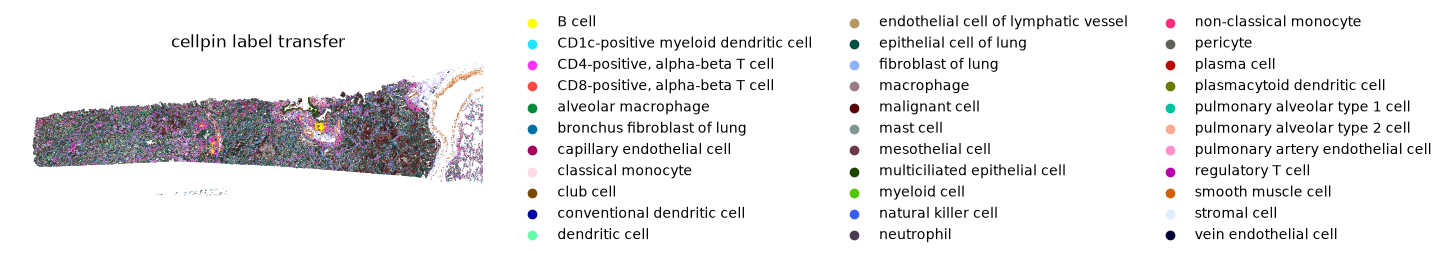

In [14]:
sc.pl.spatial(
    adata,
    color="cellpin_annotation",
    spot_size=15,
    frameon=False,
    title="cellpin label transfer",
)

---
# 4) How much spurious B-cell signal is there?

`MS4A1` (CD20) and `CD79A` are about as lineage-restricted as markers get: outside the B/plasma
compartment they should be flat zero. Any epithelial cell carrying them is reporting diffusion or a
segmentation error, not biology.



In [53]:
B_MARKERS = ["MS4A1", "CD79A"]


In the measured panel the B-cell markers are detectable in a sizeable fraction of *every* cell type:
the dot for epithelial and malignant populations is far from empty. After denoising the signal
collapses onto the B-cell and plasma-cell groups.

Let us put a number on it. The cleanest summary is the fraction of cells in which the marker is
detected at all, because the artefact is overwhelmingly a 1–2 count effect. We compare the raw
`counts` layer against the denoised integer `imputed` layer, so "detected" means the same thing on
both sides.

In [54]:
EPITHELIAL = [
    "malignant cell",
    "epithelial cell of lung",
    "pulmonary alveolar type 1 cell",
    "pulmonary alveolar type 2 cell",
    "club cell",
    "multiciliated epithelial cell",
]


def as_dense_vector(matrix):
    """Flatten a single-gene slice of a (possibly sparse) layer to a 1D array."""
    return np.asarray(matrix.todense() if hasattr(matrix, "todense") else matrix).ravel()


groups = {
    "B cell": (adata.obs["cellpin_annotation"] == "B cell").to_numpy(),
    "epithelial": adata.obs["cellpin_annotation"].isin(EPITHELIAL).to_numpy(),
}

rows = []
for group, mask in groups.items():
    for gene in B_MARKERS:
        measured = as_dense_vector(adata[mask, gene].layers["counts"])
        denoised = as_dense_vector(adata[mask, gene].layers["imputed"])
        rows.append(
            {
                "group": group,
                "gene": gene,
                "n_cells": int(mask.sum()),
                "pct_detected_measured": 100 * (measured > 0).mean(),
                "pct_detected_denoised": 100 * (denoised > 0).mean(),
            }
        )

print("B cell markers")
print(pd.DataFrame(rows).round(2))


B cell markers
        group   gene  n_cells  pct_detected_measured  pct_detected_denoised
0      B cell  MS4A1     1897                  93.67                  99.42
1      B cell  CD79A     1897                  63.26                  99.26
2  epithelial  MS4A1    88697                   1.59                   0.01
3  epithelial  CD79A    88697                   0.84                   0.00


---
# 5) Zoom in: `MS4A1` bleed around a B-cell aggregate

Aggregate statistics can hide what is actually going on. The artefact is *spatial*: it is strongest
immediately around dense B-cell regions, exactly where a per-cell-type average washes it out.

We find the densest B-cell square in the section, then cut a thin horizontal strip through it so the
individual cell polygons are large enough to read.

In [17]:
window = find_densest_square(
    sdata,
    cell_type="B cell",
    cell_type_col="cellpin_annotation",
    square_size=500.0,
    stride=25.0,
    shapes_key=SHAPES_KEY,
    table_key=TABLE_KEY,
)
print("Densest square (x_min, x_max, y_min, y_max):", window)

Densest 500 um square for 'B cell': 920 cells
Densest square (x_min, x_max, y_min, y_max): (np.float64(6688.1627177857035), np.float64(7188.1627177857035), np.float64(1612.0612678665434), np.float64(2112.0612678665434))


We strip the square into a rectangle for better visualisation

In [47]:
BCELL_SQUARE = {
    "x_min": 6688.1627177857035,
    "x_max": 7188.1627177857035,
    "y_min": 1612.0612678665434,
    "y_max": 2112.0612678665434,
}
STRIP_HEIGHT = 200.0

y_center = (BCELL_SQUARE["y_min"] + BCELL_SQUARE["y_max"]) / 2
strip_ymin = y_center - STRIP_HEIGHT / 2
strip_ymax = y_center + STRIP_HEIGHT / 2

print(
    f"Strip: x [{BCELL_SQUARE['x_min']:.1f} - {BCELL_SQUARE['x_max']:.1f}]  "
    f"y [{strip_ymin:.1f} - {strip_ymax:.1f}]  ({STRIP_HEIGHT:.0f} um tall)"
)

Strip: x [6688.2 - 7188.2]  y [1762.1 - 1962.1]  (200 um tall)


`bounding_box_query` drops the table, so we subset by polygon centroid instead and rebuild a small
`SpatialData` holding just the strip.

In [48]:
table_full = sdata.tables[TABLE_KEY]
shapes_full = sdata.shapes[SHAPES_KEY]

common = table_full.obs_names.intersection(shapes_full.index.astype(str))
table_aligned = table_full[common]
shapes_aligned = shapes_full.loc[common]

centroids = shapes_aligned.geometry.centroid
cx, cy = centroids.x.to_numpy(), centroids.y.to_numpy()

mask = (
    (cx >= BCELL_SQUARE["x_min"]) & (cx < BCELL_SQUARE["x_max"])
    & (cy >= strip_ymin) & (cy < strip_ymax)
)
sel_ids = table_aligned.obs_names[mask]
print(f"Cells in strip: {mask.sum()}")

sdata_strip = SpatialData(
    images=sdata.images,
    labels=sdata.labels,
    shapes={SHAPES_KEY: shapes_aligned.loc[sel_ids].copy()},
    tables={TABLE_KEY: table_aligned[sel_ids].copy()},
)

Cells in strip: 1540


## 5.1 Denoised vs. measured `MS4A1`

Same cells, same normalisation, same colourmap, the only difference is which layer is rendered.
Note that each panel autoscales its colour range independently, so read the panels for *where* signal
sits rather than comparing absolute brightness across them. The cell after the figure puts numbers on
the magnitudes.

/environments/philipp.putze/micromamba/envs/cellpin/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/environments/philipp.putze/micromamba/envs/cellpin/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_27439/2450520889.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


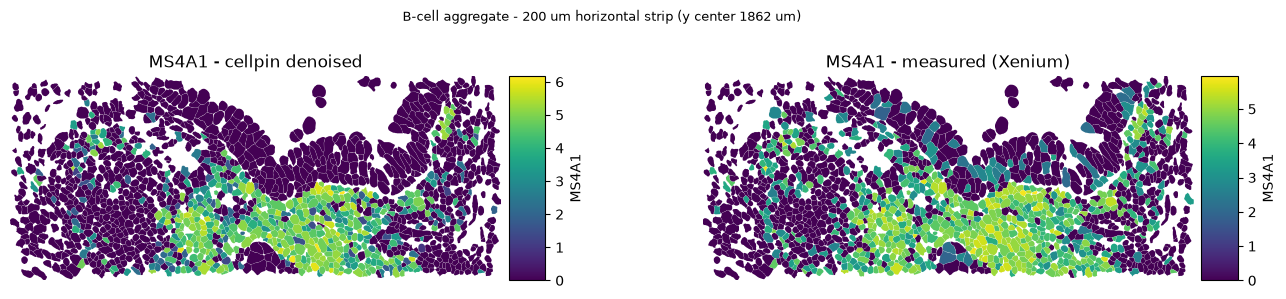

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 2.8))

sdata_strip.pl.render_shapes(
    SHAPES_KEY,
    color="MS4A1",
    table_name=TABLE_KEY,
    table_layer="imputed_norm",
    cmap="viridis",
    method="matplotlib",
    #legend=False,
    outline_alpha=0,
    outline_width=0,
).pl.show(ax=axes[0], title="MS4A1 - cellpin denoised", coordinate_systems="global")

sdata_strip.pl.render_shapes(
    SHAPES_KEY,
    color="MS4A1",
    table_name=TABLE_KEY,
    table_layer="log1p_norm",
    cmap="viridis",
    method="matplotlib",
    #legend=False,
    outline_alpha=0,
    outline_width=0,
).pl.show(ax=axes[1], title="MS4A1 - measured (Xenium)", coordinate_systems="global")

for ax in axes:
    ax.set_axis_off()
    ax.set_aspect("equal")

fig.suptitle(
    f"B-cell aggregate - {STRIP_HEIGHT:.0f} um horizontal strip (y center {y_center:.0f} um)",
    fontsize=9,
    y=1.02,
)
fig.tight_layout()
plt.show()

Read the two panels together. On the right, `MS4A1` is a smear: the aggregate is obvious, but so is a
halo of dim-but-nonzero signal running through the surrounding epithelium and stroma. That halo is
transcript diffusion plus segmentation bleed, and it is precisely the signal that would show up as
"B-cell-like" contamination in any neighbourhood or cell–cell communication analysis.

On the left, the boundary is crisp. The B cells retain their expression; their neighbours are zero.
Cellpin did not threshold or spatially smooth anything (it never saw spatial coordinates during training). The halo cells simply have transcriptomes
that the reference recognises as epithelial, and essentially no epithelial cell in the reference
expresses `MS4A1`.



## 5.2 The same crop, coloured by cell type



/environments/philipp.putze/micromamba/envs/cellpin/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


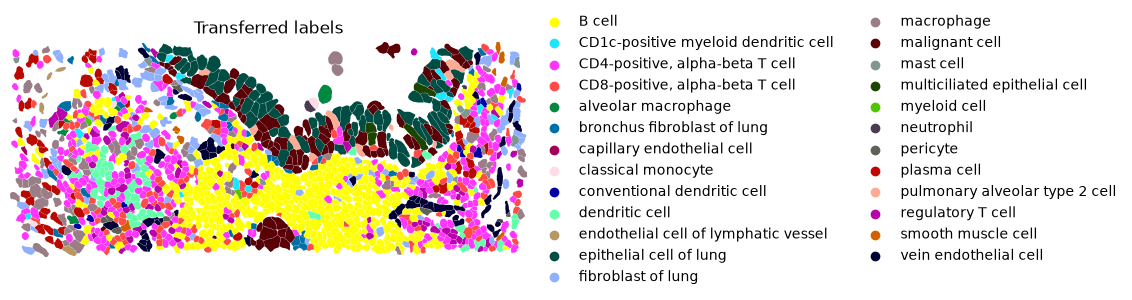

In [52]:

fig, ax = plt.subplots(figsize=(7, 2.8))
sdata_strip.pl.render_shapes(
    SHAPES_KEY,
    color="cellpin_annotation",
    table_name=TABLE_KEY,
    palette=["#D62728", "#BDBDBD"],
    method="matplotlib",
    outline_alpha=0,
    outline_width=0,
).pl.show(ax=ax, title="Transferred labels", coordinate_systems="global")
ax.set_axis_off()
ax.set_aspect("equal")
plt.show()

---
## Takeaways

- The `MS4A1` signal outside the aggregate sits on cells that cellpin, the reference atlas, and the
  remaining panel genes all agree are epithelial. It is an artefact of the measurement, not a
  rare double-positive population.
- Denoising happens as a side effect of imputation. There is no separate "denoise" step and no
  spatial smoothing. Using `return_int=True` and reading `imputed` / `imputed_norm` instead of the
  raw layers is the whole intervention.
- This matters most for the analyses that are most sensitive to it: neighbourhood enrichment,
  cell–cell communication, and any marker-based gating, all of which will otherwise read diffusion as
  co-expression.
- Keep the measured layers around. Comparing `log1p_norm` against `imputed_norm` on known lineage
  markers, as above, is the cheapest available check that the model is removing artefact rather than
  biology.

Related tutorials: [Basic usage](cellpin_tutorial.ipynb) for the core imputation workflow, and
[Label transfer](label_transfer.ipynb) for annotating spatial data from a reference atlas.